<a href="https://colab.research.google.com/github/RytisBalt/Finansinis-intelektas/blob/FinansinisIntelektas3/FI_ND3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('drive')

Mounted at drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go #
import yfinance as yf

df = yf.download('MSFT', start = '2019-01-01', end = '2023-01-01')

[*********************100%%**********************]  1 of 1 completed


<ipython-input-9-ce04cf397098>:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Stop_Loss_Price'] = np.nan


KeyError: ignored

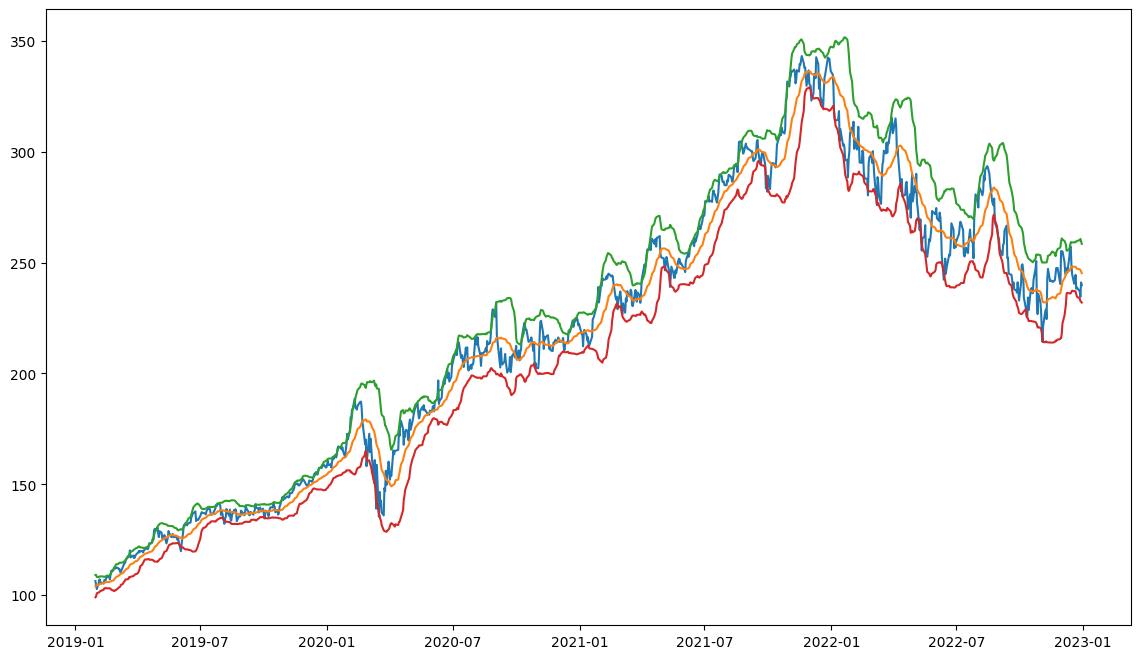

In [ ]:
def add_bollinger_bands(df, window=20):
    df['SMA'] = df.Close.rolling(window=window).mean()
    df['stddev'] = df.Close.rolling(window=window).std()
    df['Upper'] = df.SMA + 2 * df.stddev
    df['Lower'] = df.SMA - 2 * df.stddev
    df['Buy_Signal'] = np.where(df.Lower > df.Close, True, False)
    df['Sell_Signal'] = np.where(df.Upper < df.Close, True, False)
    df = df.dropna()
    return df

stop_loss_percent = 0.02
def add_stop_loss(df, stop_loss_percent):
    buys = []
    sells = []
    open_pos = False
    entry_price = 0
    stop_loss_price = 0

    for i in range(len(df)):
        if df.Lower[i] > df.Close[i]:
            if open_pos == False:
                buys.append(i)
                open_pos = True
                entry_price = df.Close[i]
                stop_loss_price = entry_price * (1 - stop_loss_percent)
            else:
                if df.Low[i] < stop_loss_price:
                    sells.append(i)
                    open_pos = False
                    entry_price = 0
                    stop_loss_price = 0
                elif df.Upper[i] < df.Close[i]:
                    sells.append(i)
                    open_pos = False
                    entry_price = 0
                    stop_loss_price = 0
        elif df.Upper[i] < df.Close[i]:
            if open_pos:
                sells.append(i)
                open_pos = False
                entry_price = 0
                stop_loss_price = 0
            elif df.Close[i] < stop_loss_price:
                sells.append(i)
                open_pos = False
                entry_price = 0
                stop_loss_price = 0

    df['Stop_Loss_Price'] = np.nan
    for i in range(len(buys)):
        for j in range(buys[i], len(df)):
            if df.Close[j] < stop_loss_price:
                df['Stop_Loss_Price'][j] = stop_loss_price
                break

    return df, buys, sells


df, buys, sells = add_stop_loss(add_bollinger_bands(df), stop_loss_percent)

def plot_bollinger_bands(df):
    plt.figure(figsize=(14,8))
    plt.plot(df.index, df['Close'], label='Close')
    plt.plot(df.index, df['SMA'], label='SMA')
    plt.plot(df.index, df['Upper'], label='Upper')
    plt.plot(df.index, df['Lower'], label='Lower')
    plt.scatter(buys, df.loc[buys]['Close'], marker='^', color='green', label='Buy')
    plt.scatter(sells, df.loc[sells]['Close'], marker='v', color='red', label='Sell')
    plt.plot(df.index, df['Stop_Loss_Price'], label='Stop Loss', color='orange')
    plt.fill_between(df.index, df.Upper, df.Lower, color='gray', alpha=0.3)
    plt.title('Bollinger Bands of MSFT')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()


plot_bollinger_bands(df)

In [ ]:
# mean reversion

# pradinis bollinger bands variantas
# prisideda SMA, stddev, Upper, Lower, Buy ir Sell signals

def add_bollinger_bands(df, window=20):

    # suskaiciuojam SMA, stddev, Upper, and Lower
    df['SMA'] = df.Close.rolling(window=window).mean()
    df['stddev'] = df.Close.rolling(window=window).std()
    df['Upper'] = df.SMA + 2 * df.stddev
    df['Lower'] = df.SMA - 2 * df.stddev

    # suskaiciuojam buy ir sell signals
    df['Buy_Signal'] = np.where(df.Lower > df.Close, True, False)
    df['Sell_Signal'] = np.where(df.Upper < df.Close, True, False)

    # isimam na reiksmes
    df = df.dropna()

    return df

add_bollinger_bands(df)

<ipython-input-10-be19e73b49a9>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SMA'] = df.Close.rolling(window=window).mean()
<ipython-input-10-be19e73b49a9>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stddev'] = df.Close.rolling(window=window).std()
<ipython-input-10-be19e73b49a9>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

,Open,High,Low,Close,Adj Close,Volume,SMA,stddev,Upper,Lower,Buy_Signal,Sell_Signal,Stop_Loss_Price
Date,,,,,,,,,,,,,


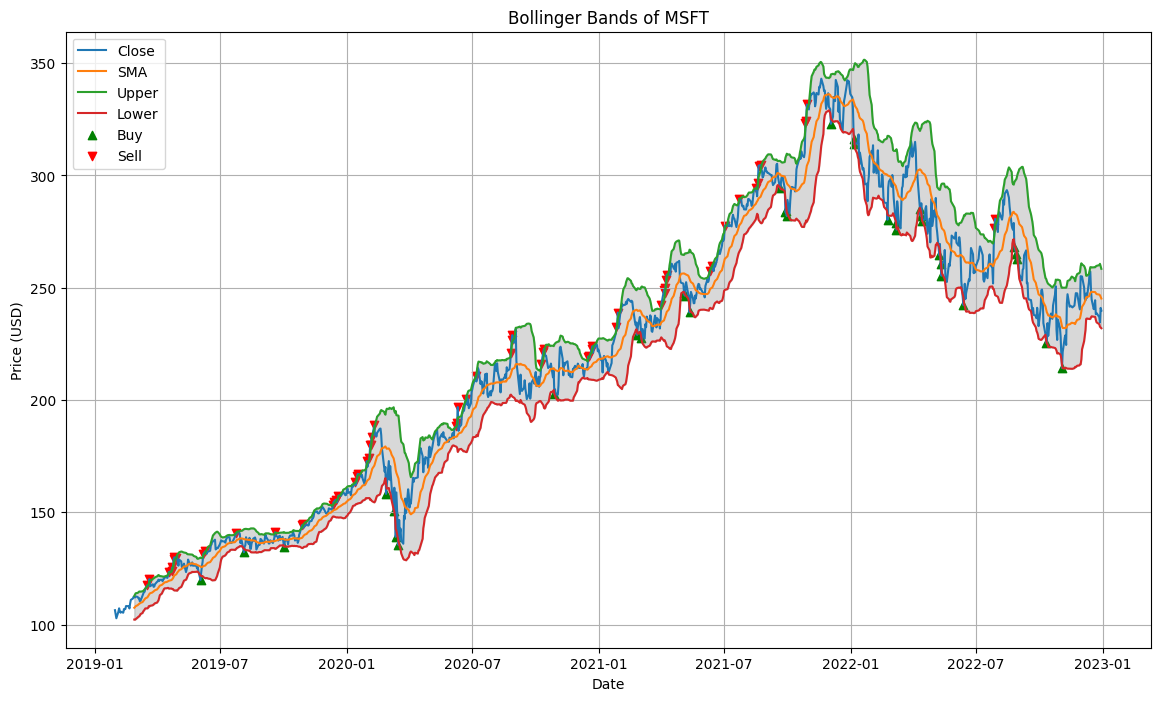

In [ ]:
# paplotinam grafika

def plot_bollinger_bands(df):
    buys = df.index[df['Buy_Signal']]
    sells = df.index[df['Sell_Signal']]

    plt.figure(figsize=(14,8))
    plt.plot(df.index, df['Close'], label='Close')
    plt.plot(df.index, df['SMA'], label='SMA')
    plt.plot(df.index, df['Upper'], label='Upper')
    plt.plot(df.index, df['Lower'], label='Lower')
    plt.scatter(buys, df.loc[buys]['Close'], marker='^', color='green', label='Buy')
    plt.scatter(sells, df.loc[sells]['Close'], marker='v', color='red', label='Sell')
    plt.fill_between(df.index, df.Upper, df.Lower, color='gray', alpha=0.3)
    plt.title('Bollinger Bands of MSFT')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

plot_bollinger_bands(df)

# signalas, kai pasiekia upper arba lower band, ir is
# eiles eina pirkimai, pardavimai (blogas pvz.)

In [ ]:
# siekiama, kad strategija butu prasminga (nebutu keli is eiles prikimai
# arba pardavimai), t.y. norima, kad butu pirkimas -> pardavimas -> pirkimas ir t.t.

buys = []
sells = []
open_pos = False # flag ar position yra open

for i in range(len(df)):
  if df.Lower[i] > df.Close[i]:
    if open_pos ==False:
      buys.append(i)
      open_pos = True
  elif df.Upper[i] < df.Close[i]:
    if open_pos:
      sells.append(i)
      open_pos = False

buys
sells

# def plot_bollinger_bands_t(df):
#   plt.figure(figsize=(14,8))
#   plt.plot(df[['Close', 'SMA', 'Upper', 'Lower']])
#   plt.scatter(df.iloc[buys].index, df.iloc[buys].Close, marker = '^', color = 'g')
#   plt.scatter(df.iloc[sells].index, df.iloc[sells].Close, marker = 'v', color = 'r')
#   # plt.fill_between(df.index, df.Upper, df.Lower, color = 'grey', alpha=0.3)
#   plt.legend(['Close', 'SMA', 'Upper', 'Lower', 'buys', 'sells'])
#   plt.show()

# plot_bollinger_bands_t(df)

[89, 161, 188, 341, 475, 547, 595, 692, 880]

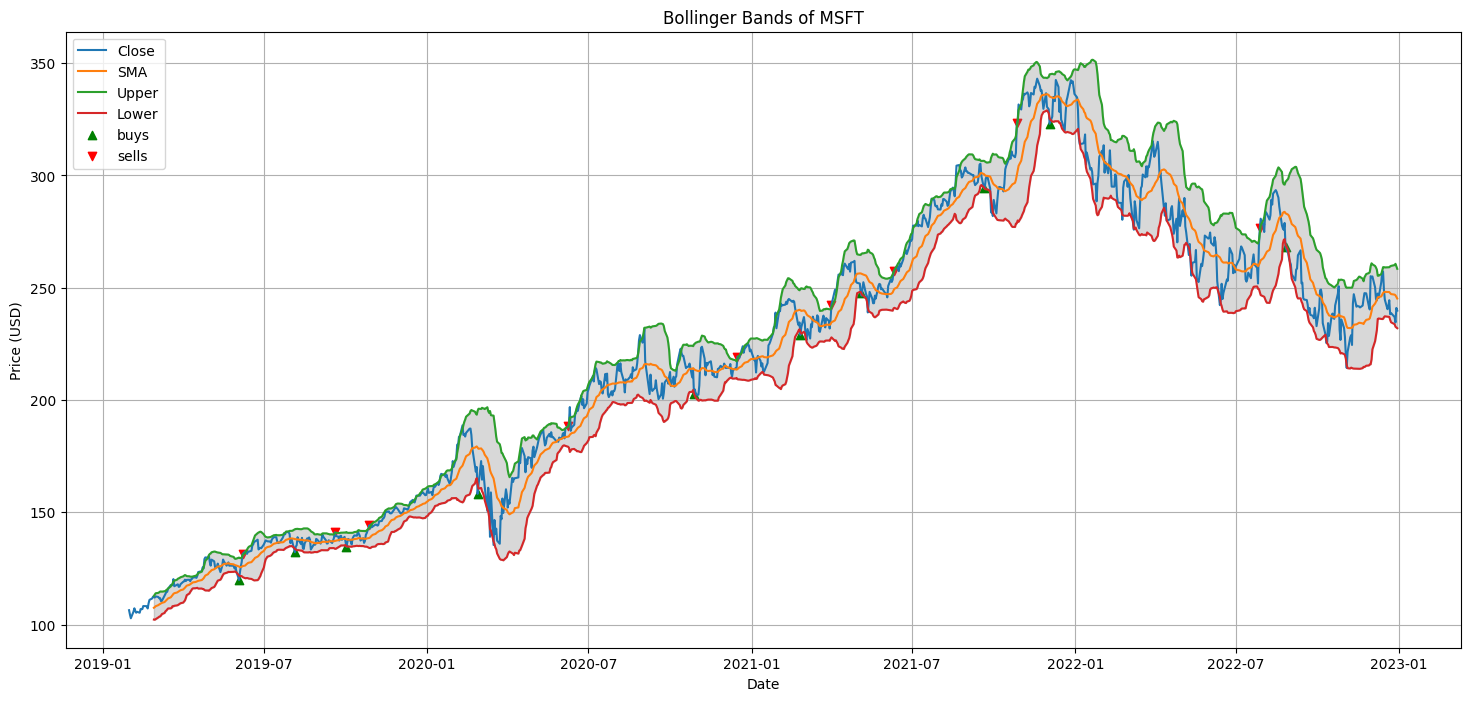

In [ ]:
def plot_bollinger_bands_t(df):
  plt.figure(figsize=(18,8))
  plt.plot(df[['Close', 'SMA', 'Upper', 'Lower']])
  plt.scatter(df.iloc[buys].index, df.iloc[buys].Close, marker = '^', color = 'g')
  plt.scatter(df.iloc[sells].index, df.iloc[sells].Close, marker = 'v', color = 'r')
  plt.fill_between(df.index, df.Upper, df.Lower, color = 'grey', alpha=0.3)
  plt.title('Bollinger Bands of MSFT')
  plt.xlabel('Date')
  plt.ylabel('Price (USD)')
  plt.legend(['Close', 'SMA', 'Upper', 'Lower', 'buys', 'sells'], loc='upper left')
  # plt.legend(loc='upper left')
  plt.grid(True)
  plt.show()

plot_bollinger_bands_t(df)

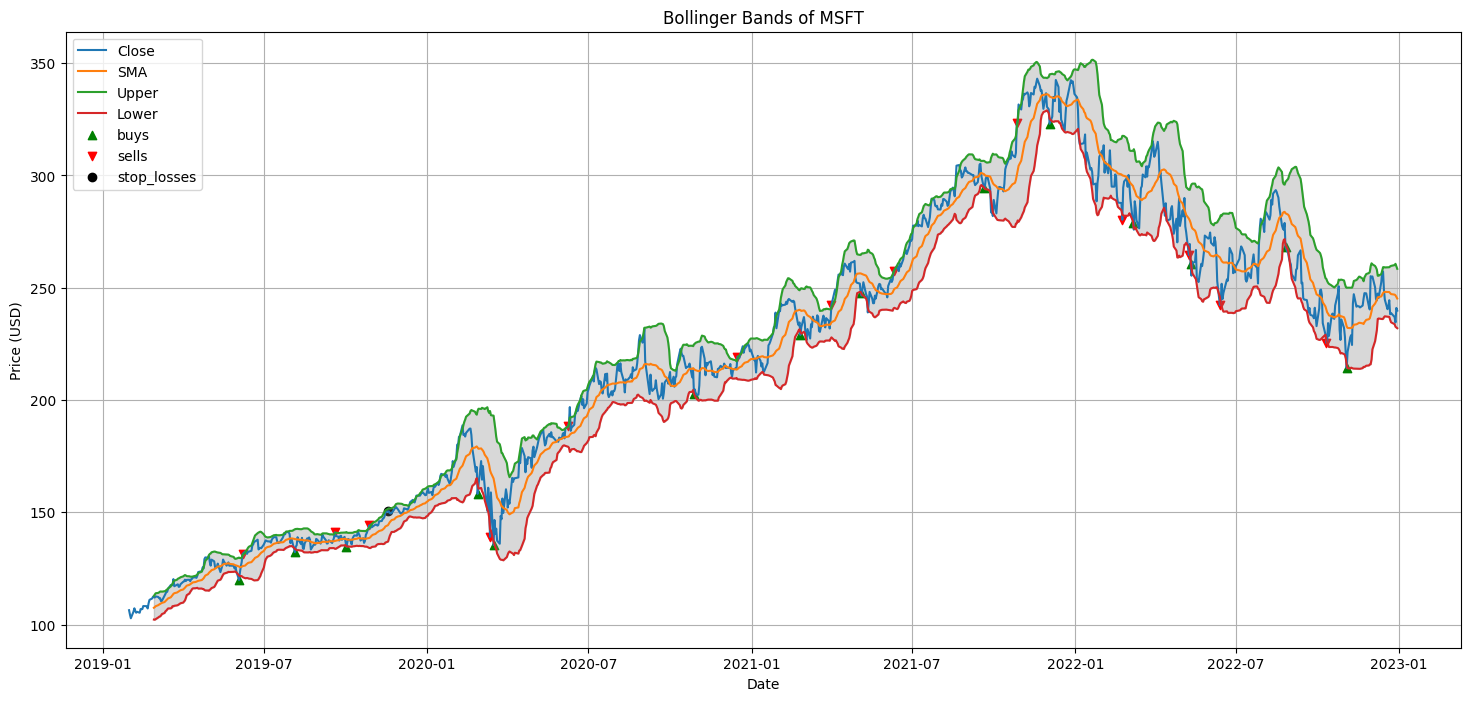

In [ ]:
buys = []
sells = []
stop_losses = []
open_pos = False # flag ar position yra open
stop_loss_pct = 0.05 # stop loss threshold as a percentage of the entry price

for i in range(len(df)):
    if df.Lower[i] > df.Close[i]:
        if open_pos == False:
            buys.append(i)
            open_pos = True
            stop_losses.append(df.Close[i] * (1 - stop_loss_pct)) # set stop loss level
        else:
            if df.Close[i] < stop_losses[-1]:
                sells.append(i)
                open_pos = False
                stop_losses.pop() # remove stop loss level
    elif df.Upper[i] < df.Close[i]:
        if open_pos:
            sells.append(i)
            open_pos = False
            stop_losses.pop() # remove stop loss level

buys
sells

def plot_bollinger_bands_t(df):
  plt.figure(figsize=(18,8))
  plt.plot(df[['Close', 'SMA', 'Upper', 'Lower']])
  plt.scatter(df.iloc[buys].index, df.iloc[buys].Close, marker = '^', color = 'g')
  plt.scatter(df.iloc[sells].index, df.iloc[sells].Close, marker = 'v', color = 'r')
  plt.scatter(df.iloc[stop_losses].index, df.iloc[stop_losses].Close, marker = 'o', color = 'black')
  plt.fill_between(df.index, df.Upper, df.Lower, color = 'grey', alpha=0.3)
  plt.title('Bollinger Bands of MSFT')
  plt.xlabel('Date')
  plt.ylabel('Price (USD)')
  plt.legend(['Close', 'SMA', 'Upper', 'Lower', 'buys', 'sells', 'stop_losses'], loc='upper left')
  # plt.legend(loc='upper left')
  plt.grid(True)
  plt.show()

plot_bollinger_bands_t(df)

In [ ]:
# backtest

merged = pd.concat([df.iloc[buys].Close, df.iloc[sells].Close], axis = 1)

merged.columns = ['Buys', 'Sells']

totalprofit = merged.shift(-1).Sells - merged.Buys

relprofits = (merged.shift(-1).Sells - merged.Buys)/merged.Buys

relprofits.mean()

0.028289968257754223

<Axes: xlabel='Date'>

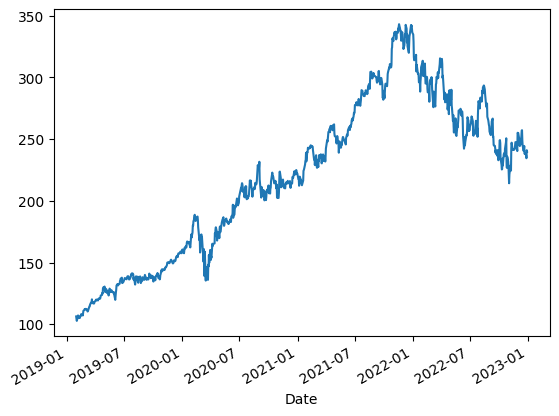

In [ ]:
df.Close.plot()

In [ ]:
df['Benchmark'] = df.Close.cummax()
df['TSL'] = df.Benchmark * 0.95
df

<ipython-input-17-fe34eac52bc6>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Benchmark'] = df.Close.cummax()
<ipython-input-17-fe34eac52bc6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TSL'] = df.Benchmark * 0.95


,Open,High,Low,Close,Adj Close,Volume,SMA,stddev,Upper,Lower,Buy_Signal,Sell_Signal,Stop_Loss_Price,Benchmark,TSL
Date,,,,,,,,,,,,,,,
2019-01-30,104.620003,106.379997,104.330002,106.379997,101.223183,49471900,NaN,NaN,NaN,NaN,False,False,NaN,106.379997,101.060997
2019-01-31,103.800003,105.220001,103.180000,104.430000,99.367706,55636400,NaN,NaN,NaN,NaN,False,False,NaN,106.379997,101.060997
2019-02-01,103.779999,104.099998,102.349998,102.779999,97.797676,35535700,NaN,NaN,NaN,NaN,False,False,NaN,106.379997,101.060997
2019-02-04,102.870003,105.800003,102.769997,105.739998,100.614189,31315100,NaN,NaN,NaN,NaN,False,False,NaN,106.379997,101.060997
2019-02-05,106.059998,107.269997,105.959999,107.220001,102.022438,27325400,NaN,NaN,NaN,NaN,False,False,NaN,107.220001,101.859001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-23,236.110001,238.869995,233.940002,238.729996,237.112076,21207000,247.169999,6.281050,259.732099,234.607899,False,False,NaN,343.109985,325.954486
2022-12-27,238.699997,238.929993,235.830002,236.960007,235.354080,16688600,246.930000,6.583089,260.096177,233.763823,False,False,NaN,343.109985,325.954486
2022-12-28,236.889999,239.720001,234.169998,234.529999,232.940552,17457100,246.639999,7.003466,260.646931,232.633068,False,False,NaN,343.109985,325.954486
